In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

import pickle
import time
import memory_profiler

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from llm_readability.word_len import create_word_length_analysis_plots

/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:83: SyntaxWarning: invalid escape sequence '\s'
  "\s*For complete details on the use and execution of this protocol.*": "",
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:86: SyntaxWarning: invalid escape sequence '\.'
  "For further information please consult linked data\.*": "",
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:88: SyntaxWarning: invalid escape sequence '\s'
  "Communicated by": {"\s*\(?Communicated by.{0,100}$": ""},
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:89: SyntaxWarning: invalid escape sequence '\.'
  "Graphical abstract": {"\.\s*Graphical abstract.*": "."},
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:90: SyntaxWarning: invalid escape sequence '\.'
  "GRAPHICAL ABSTRACT": {"\.\s*GRAPHICAL ABSTRACT.*": 

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")
berenslab_data_path = Path("/gpfs01/berens/data/data/pubmed_processed/")

In [ ]:
figures_path.exists()

True

In [ ]:
plt.style.use("matplotlib_style.txt")

In [ ]:
%watermark -a 'Rita González-Márquez' -t -d -tz -u -v -iv -w -m -h -p transformers -p openTSNE
print(distro.name(pretty=True))

Author: Rita González-Márquez

Last updated: 2025-07-21 15:36:14CEST

Python implementation: CPython
Python version       : 3.12.9
IPython version      : 9.4.0

openTSNE: not installed

Compiler    : Clang 19.1.6 
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: gber7

pathlib        : 1.0.1
black          : 25.1.0
pandas         : 2.3.1
distro         : 1.9.0
matplotlib     : 3.10.3
memory_profiler: 0.61.0
numpy          : 2.2.6
jupyter_black  : 0.4.0

Watermark: 2.5.0

Rocky Linux 8.10 (Green Obsidian)


# Load results

In [ ]:
pickle_in = open(variables_path / "results_word_len.pkl", "rb")
results_word_len = pickle.load(pickle_in)

In [ ]:
results_word_len

{'years': array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024, 2025]),
 'word_lengths': array([1, 2, 3, ..., 3, 3, 3], shape=(294234,)),
 'count_matrix': array([[2110448, 2273315, 2491466, ..., 4559278, 4905555, 3054205],
        [   6416,    7277,    8053, ...,   13343,   13945,    8656],
        [   1739,    1780,    2330, ...,    3239,    3688,    2625],
        ...,
        [      0,       0,       6, ...,       4,       1,       8],
        [      4,       0,       2, ...,       1,       9,       3],
        [      8,      12,       0, ...,      15,       4,       7]],
       shape=(294234, 16)),
 'length_distribution': {},
 'mean_length': array([5.59099471, 5.59630041, 5.59902747, 5.61077897, 5.61788641,
        5.62244967, 5.62916711, 5.64030299, 5.64086329, 5.64276489,
        5.64336838, 5.64908615, 5.65211557, 5.67057112, 5.73548867,
        5.81730133]),
 'median_length': array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5

## Plot 1

In [ ]:
# create_word_length_analysis_plots(results_word_len)

## Plot 2

In [ ]:
results_word_len.keys()

dict_keys(['years', 'word_lengths', 'count_matrix', 'length_distribution', 'mean_length', 'median_length', 'std_length', 'length_percentiles', 'length_category_counts', 'weighted_length_stats'])

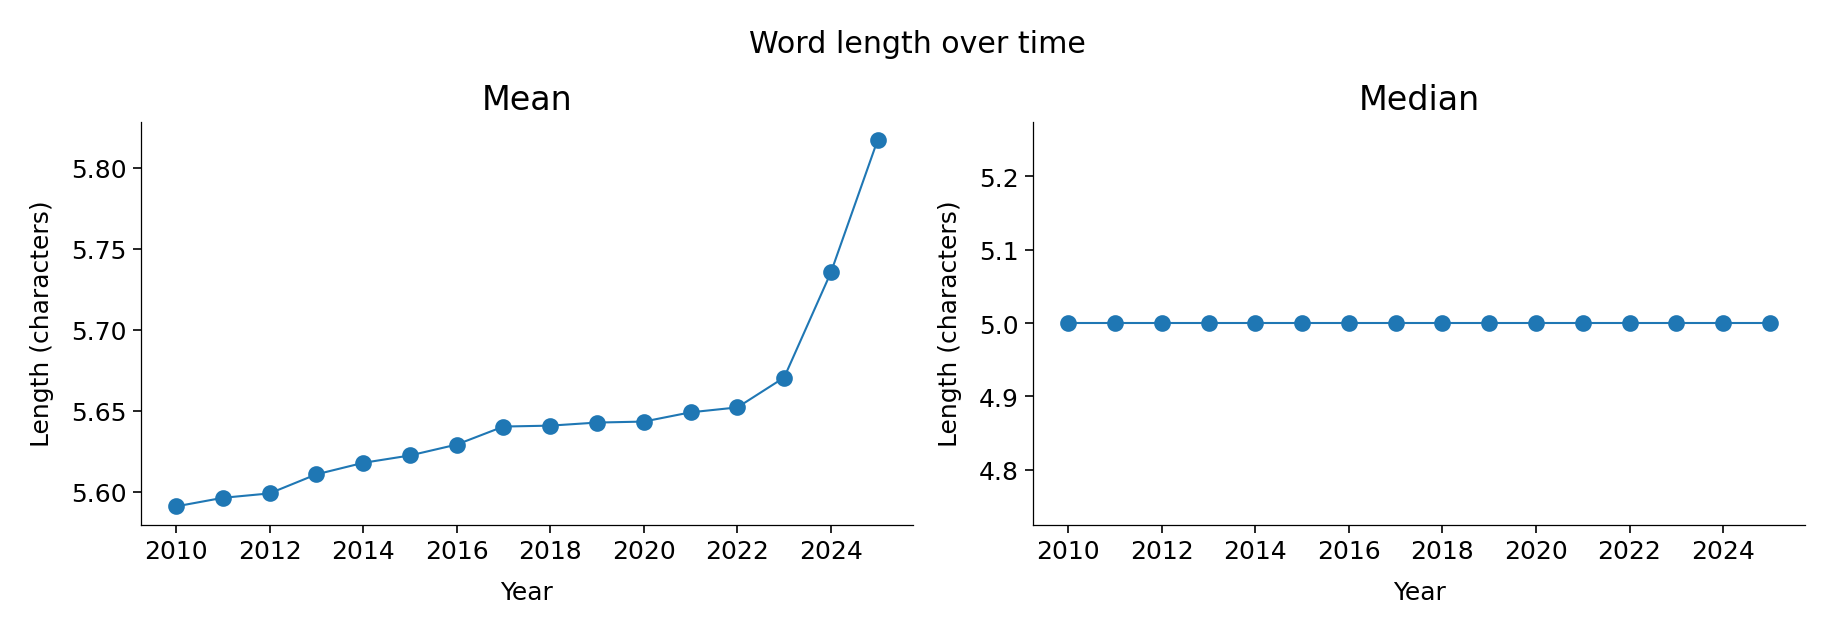

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2))
fig.suptitle("Word length over time")  # , fontsize=16, fontweight="bold")

years = results_word_len["years"]

# Mean
axes[0].plot(
    years,
    results_word_len["mean_length"],
    marker=".",
    # linewidth=2,
    label="Mean",
)
# axes[0].fill_between(
#     years,
#     results_word_len["mean_length"] - results_word_len["std_length"],
#     results_word_len["mean_length"] + results_word_len["std_length"],
#     alpha=0.3,
#     # label="±1 STD",
# )

axes[0].set_title("Mean")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Length (characters)")

# Median
axes[1].plot(
    years, results_word_len["median_length"], label="Median", marker="."
)
axes[1].set_title("Median")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Length (characters)")

fig.savefig(figures_path / "word_length_over_time.png")

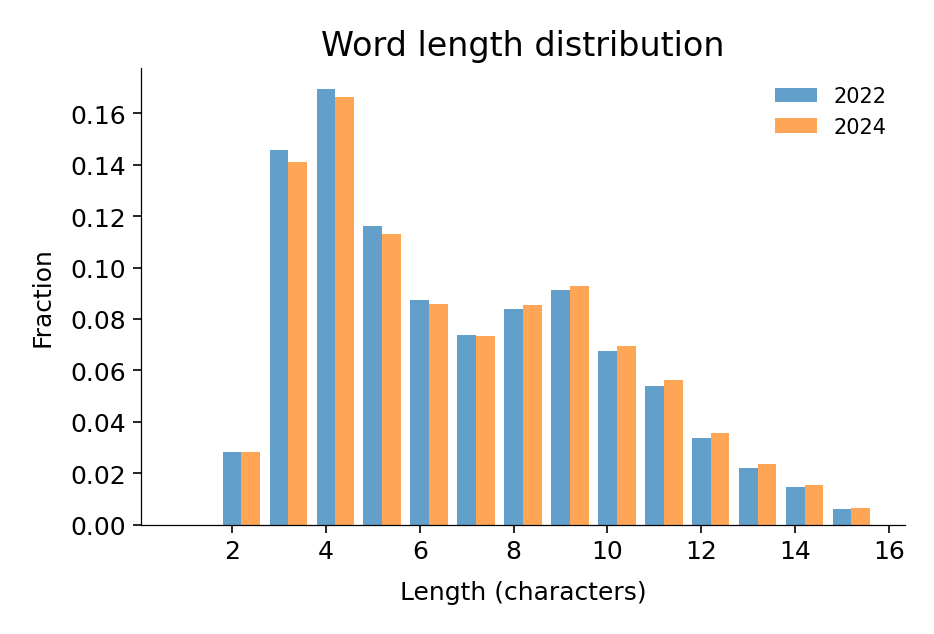

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


first_year = str(2022)
# first_year = str(2010)
last_year = str(2024)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

axes.bar(
    first_data["lengths"][:15],
    first_data["proportions"][:15],
    alpha=0.7,
    label=first_year,
    width=0.4,
)
axes.bar(
    last_data["lengths"][:15] + 0.4,
    last_data["proportions"][:15],
    alpha=0.7,
    label=last_year,
    width=0.4,
)
axes.set_title(f"Word length distribution")  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel("Fraction")
axes.legend()

fig.savefig(
    figures_path / f"word_length_distribution_{first_year}_vs_{first_year}.png"
)